dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,confusion_matrix)
try:
    from xgboost import XGBClassifier
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
    from xgboost import XGBClassifier


ModuleNotFoundError: No module named 'matplotlib'

data acquisition

In case you are trying to run this code : This code is made to run on Google colab , it might need some changes to load DATA on other IDEs

In [ ]:
data = pd.read_csv('/content/data.csv')
print(data)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   0       145   233    1        2      150      0    2.300   
1     67    1   3       160   286    0        2      108      1    1.500   
2     67    1   3       120   229    0        2      129      1    2.600   
3     37    1   2       130   250    0        0      187      0    3.500   
4     41    0   1       130   204    0        2      172      0    1.400   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   45    1   0       110   264    0        0      132      0    1.200   
299   68    1   3       144   193    1        0      141      0    3.400   
300   57    1   3       130   131    0        0      115      1    1.200   
301   57    0   1       130   236    0        2      174      0    0.000   
302   38    1   2       138   175    0        0      173      0    0.000   

     slope  ca  thal  target  
0        2   0     2       0  
1        1   3     1     

In [ ]:
#What dose the dataframe look like?

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.300,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.500,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.600,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.500,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.400,0,0,1,0


In [ ]:
#(rows,columns)
data.shape

(303, 14)

In [ ]:
# lists all the columns and tells us if there is any missing values in dataset and the datatypes of attributes
# for me all are "303 non-null", it means there is no missing values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,303.000,54.439,9.039,29.000,48.000,56.000,61.000,77.000
sex,303.000,0.680,0.467,0.000,0.000,1.000,1.000,1.000
cp,303.000,2.158,0.960,0.000,2.000,2.000,3.000,3.000
trestbps,303.000,131.690,17.600,94.000,120.000,130.000,140.000,200.000
chol,303.000,246.693,51.777,126.000,211.000,241.000,275.000,564.000
fbs,303.000,0.149,0.356,0.000,0.000,0.000,0.000,1.000
restecg,303.000,0.990,0.995,0.000,0.000,1.000,2.000,2.000
thalach,303.000,149.607,22.875,71.000,133.500,153.000,166.000,202.000
exang,303.000,0.327,0.470,0.000,0.000,0.000,1.000,1.000
oldpeak,303.000,1.040,1.161,0.000,0.000,0.800,1.600,6.200


data filter (working on outliers, errors/noise,duplicates and invalid data)

In [ ]:
#making it easiser to read data
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
import missingno as msno

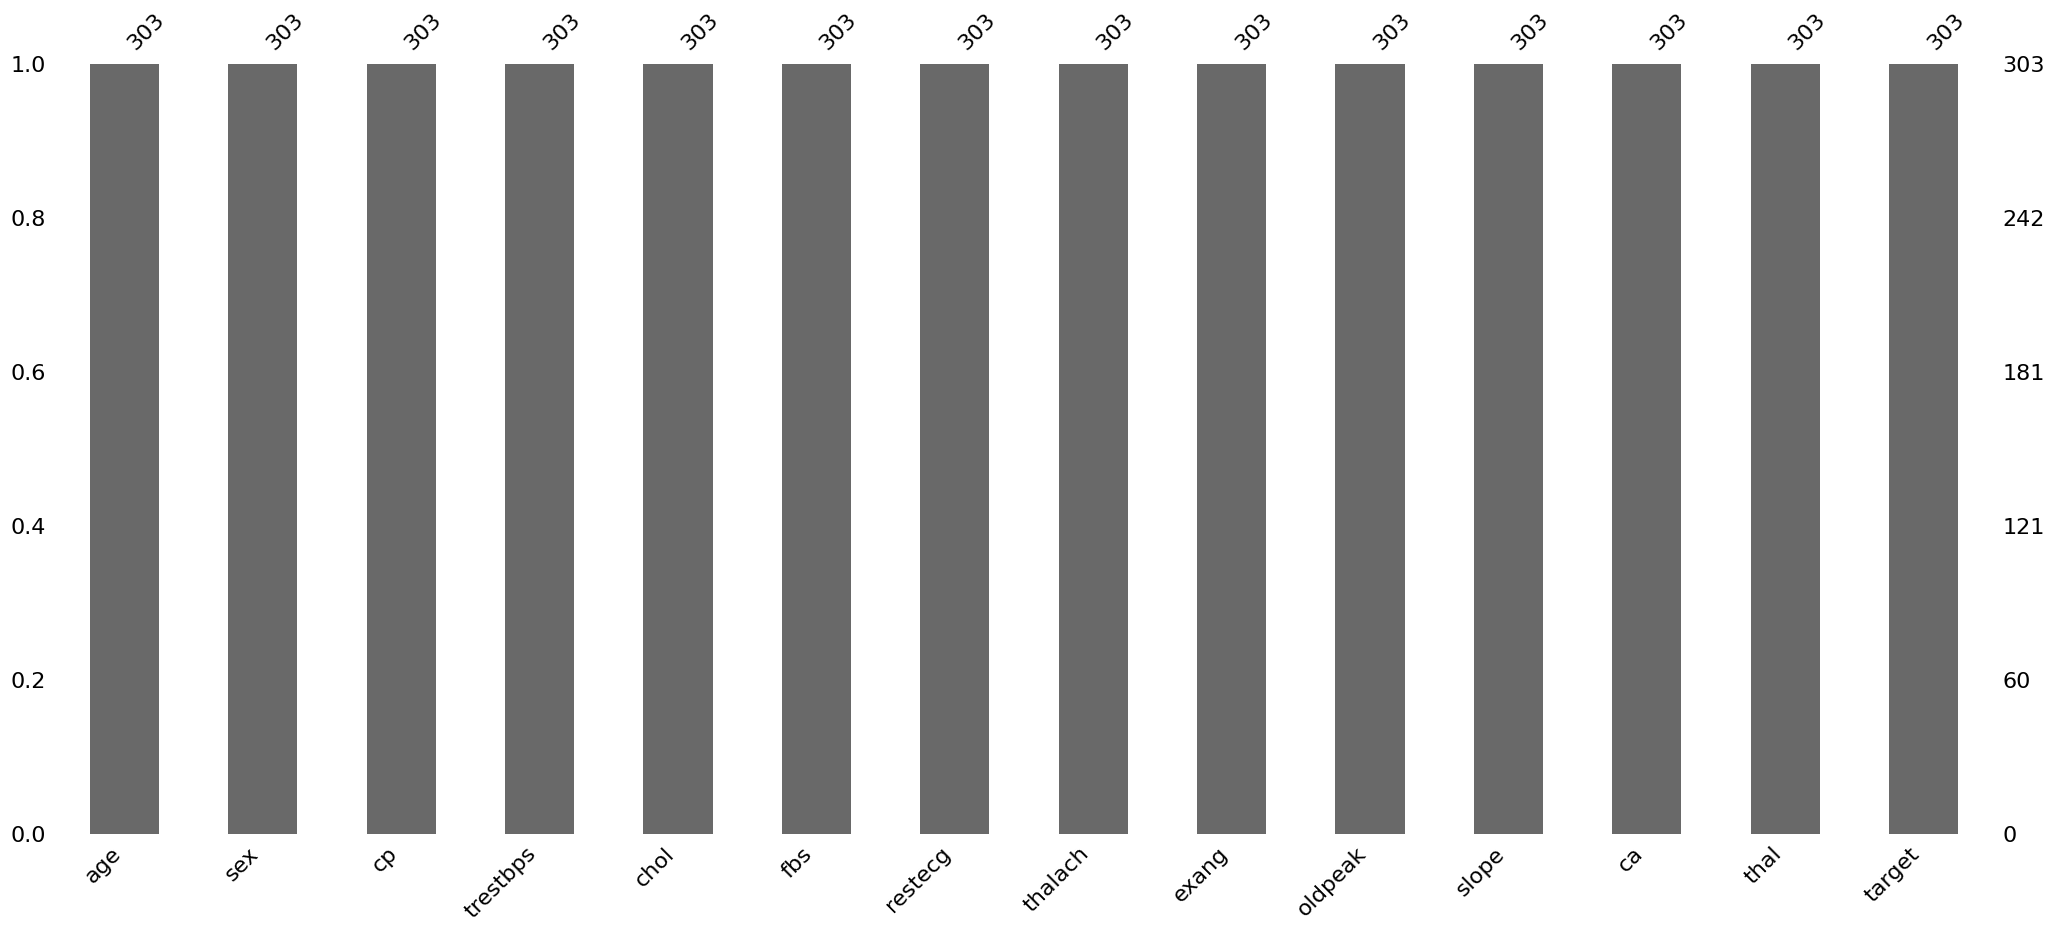

In [ ]:
msno.bar(data)
plt.show()

since there are no missing values we can skip the part where we "deal with the missing values"

to deal with it :


to deal with missing values we genrally,
i. replace the values with mean if missingness < 10%
       data['attribute_name'] = data['attribute_name'].fillna(data['attribute_name'].mean())
ii. for missingness > 10%, we can drop those rows
       data = data.dropna()


checking for duplicates


In [ ]:
data.duplicated().sum()

np.int64(0)

EDA

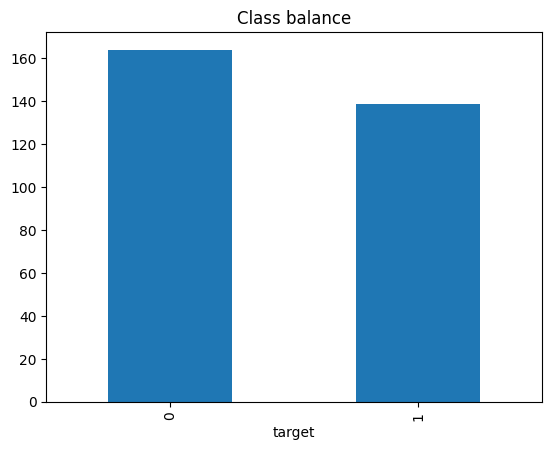

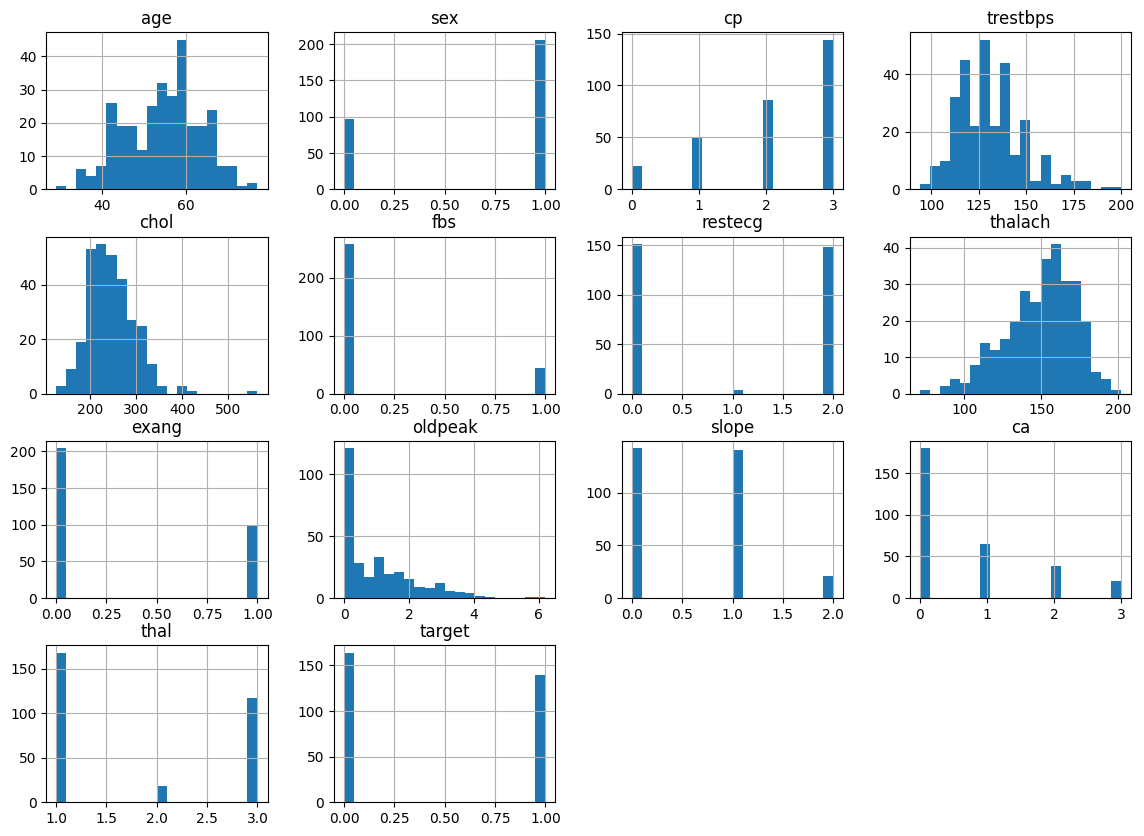

In [ ]:
# 1. Class balance
data['target'].value_counts().plot(kind='bar')
plt.title('Class balance')
plt.show()

# 2. Feature distributions split by target,.shows which features separate classes
data.hist(bins=20, figsize=(14,10))
plt.show()

treating outliers

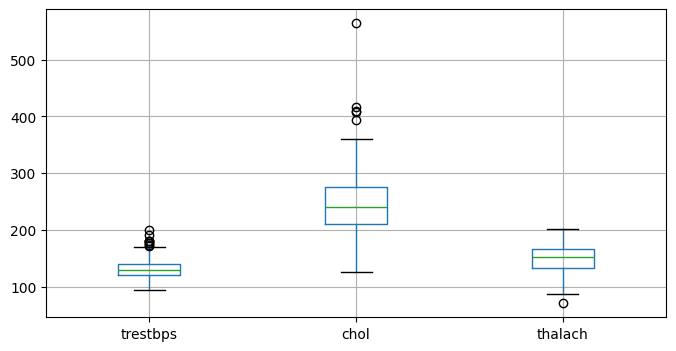

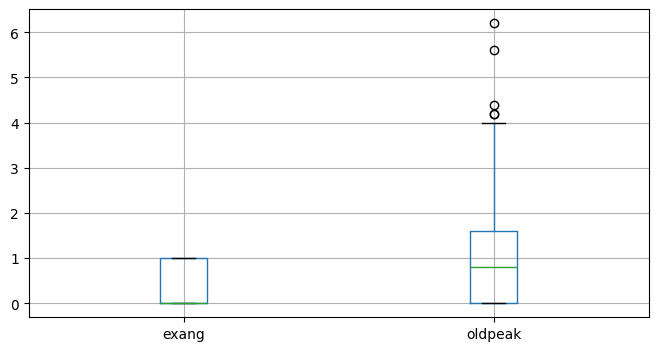

In [ ]:
# 3. Boxplots — spot outliers visually
data[['trestbps', 'chol', 'thalach']].boxplot(figsize=(8,4))
plt.show()
data[['exang', 'oldpeak']].boxplot(figsize=(8,4))
plt.show()

#cp, slope, thal, restecg are categorical variables, so boxplots can be misleading.

In [ ]:
def cap_outliers(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column_name] = df[column_name].clip(lower_bound, upper_bound)
    return df

for column_name in ['trestbps', 'chol', 'thalach']:
        data = cap_outliers(data, column_name)

data['oldpeak'] = np.log1p(data['oldpeak'])



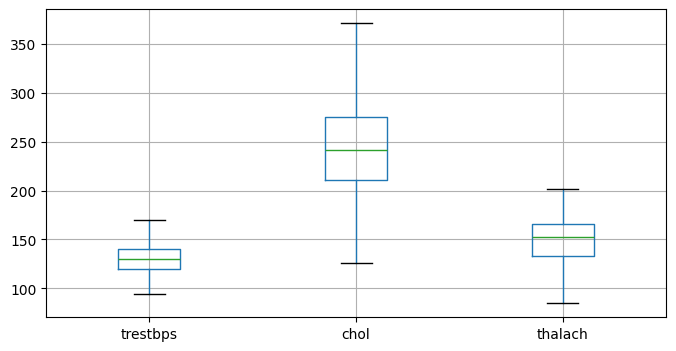

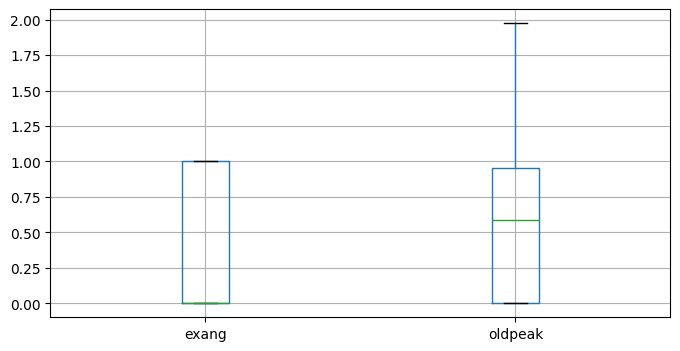

In [ ]:
#new updated Boxplots
data[['trestbps', 'chol','thalach']].boxplot(figsize=(8,4))
plt.show()
data[[ 'exang', 'oldpeak']].boxplot(figsize=(8,4))
plt.show()

Train Test Split

In [ ]:

X = data.drop('target', axis=1)
y = data['target']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print(f"Train size : {X_train.shape[0]} rows")
print(f"Test size  : {X_test.shape[0]} rows")
print(f"Train class balance:\n{y_train.value_counts()}")

print(f"\nShape after preprocessing:")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")

Train size : 242 rows
Test size  : 61 rows
Train class balance:
target
0    131
1    111
Name: count, dtype: int64

Shape after preprocessing:
  X_train : (242, 13)
  X_test  : (61, 13)


model training

scaling all the models

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Defining models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Neural Network (MLP)": MLPClassifier(
        hidden_layer_sizes=(32, 16), max_iter=1000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42
    ),
    "SVC": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric="logloss", random_state=42
    ),
}

all models training and evaluation

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Disease Precision": prec,
        "Disease Recall": rec,
        "Disease F1": f1,
    })

    results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
print("\n=== Model Comparison ===")
print(results_df.round(3))


=== Model Comparison ===
                  Model  Accuracy  Disease Precision  Disease Recall  \
0         Random Forest     0.902              0.844           0.964   
1   Logistic Regression     0.869              0.812           0.929   
2                   SVC     0.869              0.833           0.893   
3               XGBoost     0.852              0.788           0.929   
4  Neural Network (MLP)     0.820              0.730           0.964   

   Disease F1  
0       0.900  
1       0.867  
2       0.862  
3       0.852  
4       0.831  


bar chart for comparison

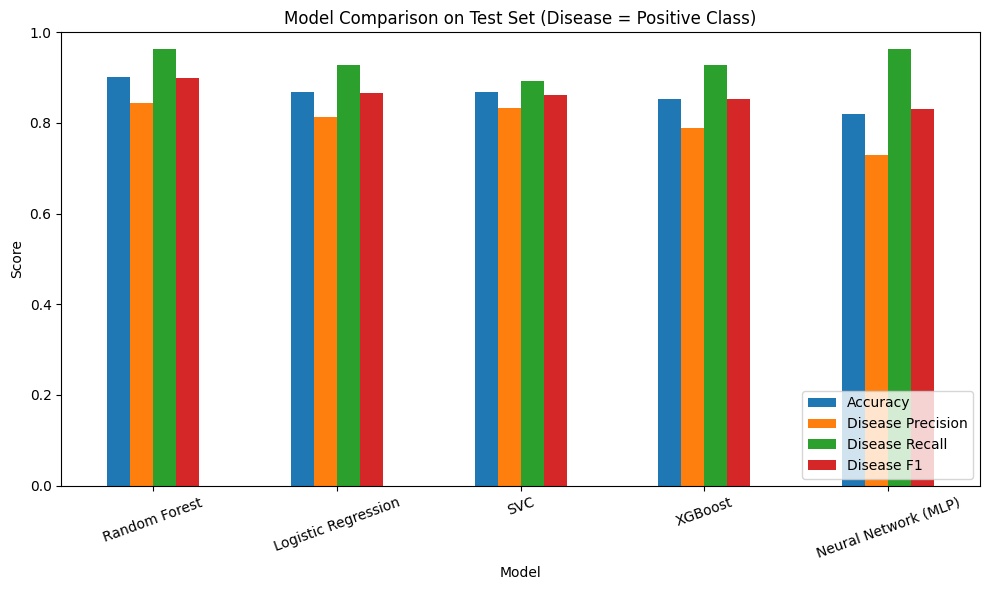

In [ ]:
results_df.set_index('Model')[['Accuracy', 'Disease Precision', 'Disease Recall', 'Disease F1']].plot(
    kind='bar', figsize=(10, 6), ylim=(0, 1)
)
plt.title('Model Comparison on Test Set (Disease = Positive Class)')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Best model declaration

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
print(f"\nBest performing model by Accuracy: {best_model_name}")


Best performing model by Accuracy: Random Forest


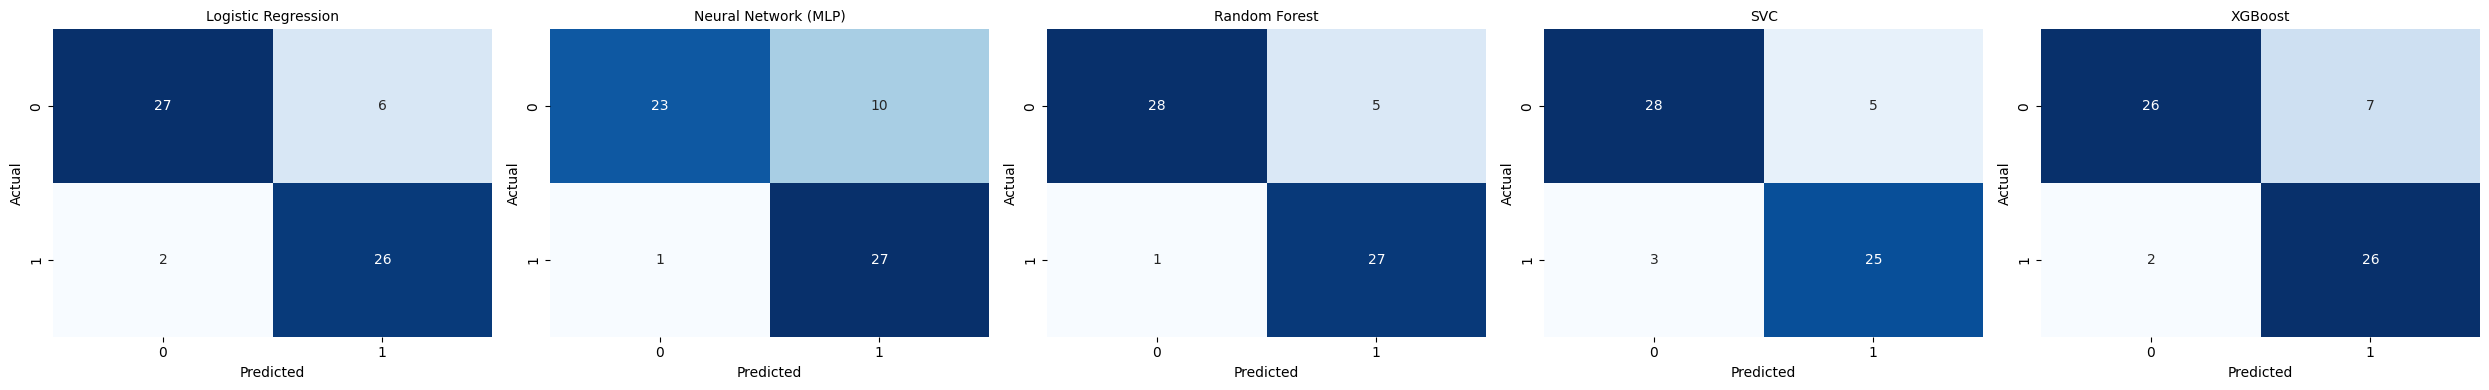

In [ ]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

fitted_models = {}
roc_data = {}

for name, m in models.items():
    m.fit(X_train_scaled, y_train)
    fitted_models[name] = m

    if hasattr(m, 'predict_proba'):
        disease_proba = m.predict_proba(X_test_scaled)[:, 1]
    else:
        # fallback for models without predict_proba
        disease_proba = m.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, disease_proba, pos_label=1)
    auc_score = roc_auc_score(y_test, disease_proba)
    roc_data[name] = (fpr, tpr, auc_score)
    print(f'{name:22s}: AUC = {auc_score:.4f}')

Logistic Regression   : AUC = 0.9459
Neural Network (MLP)  : AUC = 0.9253
Random Forest         : AUC = 0.9589
SVC                   : AUC = 0.9426
XGBoost               : AUC = 0.9188


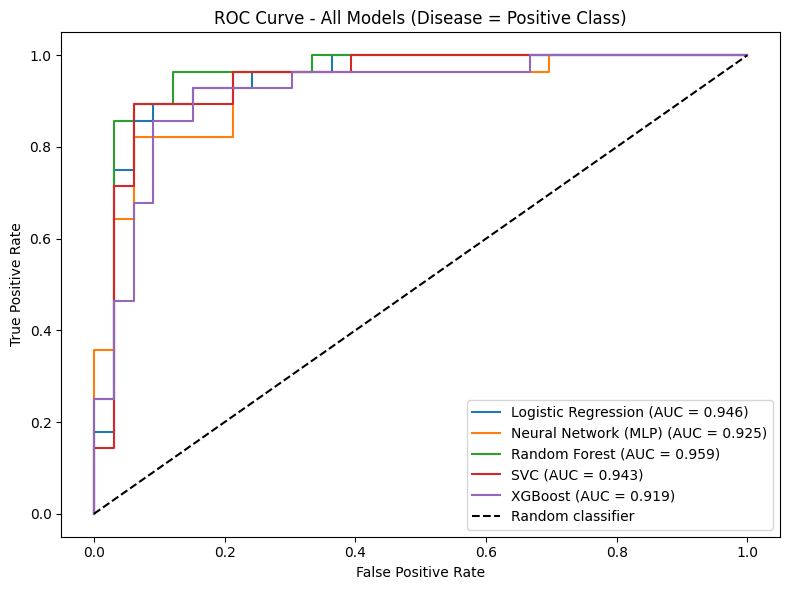

In [ ]:
plt.figure(figsize=(8, 6))

for name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.title('ROC Curve - All Models (Disease = Positive Class)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]

print(f'Best model: {best_model_name}\n')
print(classification_report(y_test, best_model.predict(X_test_scaled),
                             target_names=['No Disease', 'Disease']))

Best model: Random Forest

              precision    recall  f1-score   support

  No Disease       0.97      0.85      0.90        33
     Disease       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



In [ ]:
print(f'Best model ready for use: {best_model_name}')
print('No files written to disk -- best_model and scaler are used directly from memory.')

Best model ready for use: Random Forest
No files written to disk -- best_model and scaler are used directly from memory.


In [ ]:
input_data = (57, 0, 3, 120, 354, 0, 0, 163, 1, 0.6, 0, 0, 1)

input_df = pd.DataFrame([input_data], columns=X.columns)

# apply the same scaling used during training
input_scaled = scaler.transform(input_df)

prediction = best_model.predict(input_scaled)
print(prediction)

if prediction[0] == 0:
    print('The Person does not have a Heart Disease')
else:
    print('The Person has Heart Disease')

[0]
The Person does not have a Heart Disease


## Predict for a new patient

End-to-end inference on one raw record. `predict_new_patient` repeats the exact preprocessing used for training: IQR capping (bounds from the raw data), `log1p` on `oldpeak`, then the fitted `StandardScaler`.

Coding used in `data.csv`: `cp` 0 typical angina, 1 atypical, 2 non-anginal, 3 asymptomatic; `restecg` 0 normal, 1 ST-T abnormality, 2 LV hypertrophy; `slope` 0 up, 1 flat, 2 down; `thal` 1 normal, 2 fixed defect, 3 reversible defect.

In [ ]:
FEATURES = list(X.columns)

# capping bounds must come from the RAW data (the notebook's `data` was capped in place above)
raw = pd.read_csv('/content/data.csv')
BOUNDS = {}
for c in ['trestbps', 'chol', 'thalach']:
    q1, q3 = raw[c].quantile(0.25), raw[c].quantile(0.75)
    BOUNDS[c] = (q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1))

def transform_record(record):
    row = pd.DataFrame([{f: float(record[f]) for f in FEATURES}])
    for c, (lo, hi) in BOUNDS.items():
        row[c] = row[c].clip(lo, hi)
    row['oldpeak'] = np.log1p(row['oldpeak'])
    return scaler.transform(row[FEATURES].values)

def predict_new_patient(record, model_name='Random Forest'):
    return fitted_models[model_name].predict_proba(transform_record(record))[0, 1]

new_patient = dict(age=61, sex=1, cp=3, trestbps=140, chol=207, fbs=0, restecg=2,
                   thalach=138, exang=1, oldpeak=1.9, slope=0, ca=1, thal=3)

for name in ['Random Forest', 'Logistic Regression', 'Neural Network (MLP)']:
    p = predict_new_patient(new_patient, name)
    print(f"{name:22s} P(disease) = {p:.3f} -> {'Disease' if p >= 0.5 else 'No disease'}")

## Export the models for the web interface

Writes `model_notebook.json` (Random Forest trees, Logistic Regression, MLP, scaler, capping bounds, metrics). Tree thresholds are stored at **full precision**: scikit-learn compares float32 inputs to them, so rounding can flip a split.

For the ready-to-use UI file (which also includes the built-in example records), run `python heart_disease_pipeline.py --data data.csv --out model.json`. For a local Python UI instead: `streamlit run app.py`.

In [ ]:
import json

rf = fitted_models['Random Forest']
lr = fitted_models['Logistic Regression']
mlp = fitted_models['Neural Network (MLP)']

trees = []
for est in rf.estimators_:
    t = est.tree_
    v = t.value[:, 0, :]
    p1 = v[:, 1] / v.sum(1)
    leaf = t.children_left == -1
    trees.append(dict(
        f=[-1 if l else int(f) for f, l in zip(t.feature, leaf)],
        t=[float(p1[i]) if leaf[i] else float(t.threshold[i]) for i in range(t.node_count)],
        l=t.children_left.tolist(), r=t.children_right.tolist()))

metrics = []
for name, m in fitted_models.items():
    pred = m.predict(X_test_scaled)
    proba = m.predict_proba(X_test_scaled)[:, 1]
    metrics.append(dict(model={'Neural Network (MLP)': 'MLP'}.get(name, name),
                        acc=round(accuracy_score(y_test, pred), 3), prec=round(precision_score(y_test, pred), 3),
                        rec=round(recall_score(y_test, pred), 3), f1=round(f1_score(y_test, pred), 3),
                        auc=round(roc_auc_score(y_test, proba), 3), cm=confusion_matrix(y_test, pred).tolist()))

CONT = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
export = dict(
    cols=FEATURES,
    bounds={k: [float(a), float(b)] for k, (a, b) in BOUNDS.items()},
    mean=scaler.mean_.tolist(), scale=scaler.scale_.tolist(),
    lr=dict(w=lr.coef_[0].tolist(), b=float(lr.intercept_[0])),
    mlp=dict(W=[w.tolist() for w in mlp.coefs_], B=[b.tolist() for b in mlp.intercepts_]),
    rf=trees,
    ref={c: (float(raw[c].median()) if c in CONT else int(raw[c].mode()[0])) for c in FEATURES},
    rng={c: [float(raw[c].min()), float(raw[c].max())] for c in FEATURES},
    metrics=metrics, imp=dict(zip(FEATURES, rf.feature_importances_.tolist())),
    split=dict(train=len(X_train), test=len(X_test)))

with open('model_notebook.json', 'w') as f:
    json.dump(export, f, separators=(',', ':'))
print('saved model_notebook.json')